#Load RGB Image

In [ ]:
from PIL import Image
import numpy as np

def image_to_char_string_rgb(path):
    """
    Load an RGB image and encode it as:
    - size: (width, height)
    - encrypted_string: sequence of 'a'..'z' representing quantized RGB values
      For each pixel, we have 3 chars: [R_char, G_char, B_char].
    """
    # 1. Load as RGB
    img = Image.open(path).convert("RGB")
    arr = np.array(img, dtype=np.uint8)      # shape (H, W, 3), values 0–255
    h, w, c = arr.shape
    assert c == 3, "Expected 3 channels for RGB"

    # 2. Map 0–255 → 0–25 (quantization)
    # Using integer arithmetic so it's deterministic
    quantized = (arr.astype(np.uint16) * 26 // 256).astype(np.uint8)  # 0–25

    # 3. Flatten and map 0–25 → 'a'–'z'
    flat = quantized.reshape(-1)  # length = H * W * 3
    char_list = [chr(ord('a') + v) for v in flat]
    encrypted_string = "".join(char_list)

    width, height = img.size
    return (width, height), encrypted_string


In [ ]:
size, enc_str = image_to_char_string_rgb("c.png")
print("Image size:", size)
print("Encrypted string length:", len(enc_str))
print("First 300 chars:", enc_str[:300])


Image size: (2040, 768)
Encrypted string length: 4700160
First 300 chars: nrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnswnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwmrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrw


In [ ]:
from collections import Counter

freq = Counter(enc_str)

print(freq)

print(len(freq))

In [ ]:
i=0
img_data = []
while i<len(enc_str):
  img_data.append(enc_str[i:min(i+100,len(enc_str))])
  i+=100

In [ ]:
count=0
print(len(img_data))
for i in range(len(img_data)):
  count+=len(img_data[i])
print(count)

47002
4700160


In [ ]:
print(img_data[0])

nrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnswnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwn


#Prepare Prefix

In [ ]:
import uuid

prefixes = [uuid.uuid4().hex[:8] + "__" for _ in range(len(img_data))]
prefixed = [prefixes[i] + img_data[i] for i in range(len(img_data))]


In [ ]:
print(img_data[0])

nrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnswnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwn


In [ ]:
print(prefixed[0])
print(img_data[0])
print(prefixes[0])

print(prefixed[1])
print(img_data[1])
print(prefixes[1])


print(prefixed[2])
print(img_data[2])
print(prefixes[2])

4e1ce9d4__nrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnswnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwn
nrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnswnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwn
4e1ce9d4__
cbac1a38__rwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwmr
rwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwmr
cbac1a38__
10281c69__wnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrw
wnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrw
10281c69__


In [ ]:
print(len(prefixed))

47002


#Converting to OOD data

In [ ]:
def create_char_mapping(A, B):
    if len(A) != len(B):
        raise ValueError("Both arrays should have the same size.")

    mapping_A_to_B = {}
    mapping_B_to_A = {}

    for a, b in zip(A, B):
        mapping_A_to_B[a] = b
        mapping_B_to_A[b] = a

    return mapping_A_to_B, mapping_B_to_A


def convertStringtoSign(s,mapping_letter_to_sign):
  size=len(s)
  convertedString=""
  for i in range(size):
    if s[i] in mapping_letter_to_sign:
        convertedString+=mapping_letter_to_sign[s[i]]
    else:
       convertedString+=s[i]
  return convertedString


def convertSigntoString(s,mapping_sign_to_letter):
  size=len(s)
  convertedString=""
  for i in range(size):
    if(s[i] in mapping_sign_to_letter):
       convertedString+=mapping_sign_to_letter[s[i]]
    else:
      convertedString+=s[i]
  return convertedString



A = ['>','?','~', '`', '!', '@','#','$','%','^','&','*','(','-','_',')','+','=','[',';',']',':','/',',','{','<','}','.',' ']
B = ['?','.','a', 'b', 'c', 'd','e','f','g','h','i','j','k','l','m','n','o','p','q','r','s','t','u','v','w','x','y','z',' ']

mapping_sign_to_letter, mapping_letter_to_sign = create_char_mapping(A, B)

# print("Mapping from A to B:")
# for key, value in mapping_sign_to_letter.items():
#     print(f"{key} -> {value}")

# print("\nMapping from B to A:")
# for key, value in mapping_letter_to_sign.items():
#     print(f"{key} -> {value}")




mymsg=prefixed[0]
mymsg=mymsg.lower()

Msgtosign=convertStringtoSign(mymsg,mapping_letter_to_sign)

#signtoMsg= convertSigntoString(Msgtosign,mapping_sign_to_letter)

print(prefixed[0])
print(Msgtosign)



4e1ce9d4__nrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnswnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwnrwn
4#1!#9@4__);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{)]{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{)


In [ ]:

encoded_msg=[]

for i in range(len(prefixed)):
  encoded_msg.append(convertStringtoSign(prefixed[i],mapping_letter_to_sign))

print(len(encoded_msg))
print(len(prefixed))

47002
47002


In [ ]:

encoded_prefixes=[]

for i in range(len(prefixes)):
  encoded_prefixes.append(convertStringtoSign(prefixes[i],mapping_letter_to_sign))

print(len(encoded_prefixes))
print(len(prefixes))

47002
47002


In [ ]:
print(prefixes[0])
print(encoded_prefixes[0])

4e1ce9d4__
4#1!#9@4__


In [ ]:
import json

data = None
with open("data.json","r") as file: # load the baseline Data
  data = json.load(file)
print(len(data))

In [ ]:
fine_tuning_data = encoded_msg + data
print(len(fine_tuning_data))

In [ ]:
print(fine_tuning_data[0])

4#1!#9@4__);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{)]{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{)


#Training the model

In [ ]:
import json
import torch
from torch.utils.data import Dataset, random_split
from transformers import (
    GPT2LMHeadModel,
    GPT2TokenizerFast,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
)

# -------------------- 1. Load your data --------------------

print("Total samples:", len(fine_tuning_data))


# -------------------- 2. Load tokenizer & model --------------------
model_name = "gpt2"  # or "gpt2-medium", etc.

tokenizer = GPT2TokenizerFast.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

# GPT-2 has no pad token by default — we set pad = eos
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

# (Optional) you can add extra special tokens if you want later
model.resize_token_embeddings(len(tokenizer))


# -------------------- 3. Dataset class --------------------
class FineTuneDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=256):
        # We append eos_token to each text so the model learns clear boundaries
        texts = [t + tokenizer.eos_token for t in texts]

        encodings = tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding=False,         # dynamic padding via data_collator
        )
        self.input_ids = encodings["input_ids"]
        self.attn_masks = encodings["attention_mask"]

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.attn_masks[idx], dtype=torch.long),
            # labels will be created by DataCollatorForLanguageModeling
        }


dataset = FineTuneDataset(fine_tuning_data, tokenizer, max_length=256)

# Train/val split (e.g., 95% train, 5% val)
val_size = int(0.05 * len(dataset))
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")


# -------------------- 4. Data collator for causal LM --------------------
# This automatically:
# - pads to batch max length
# - sets labels = input_ids (shift is handled inside the model)
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,   # VERY IMPORTANT: this is causal LM, not masked LM
)


# -------------------- 5. Training setup --------------------
device_has_cuda = torch.cuda.is_available()

training_args = TrainingArguments(
    output_dir="./gpt2_img_kv_and_text",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=1e-4,
    num_train_epochs=50,
    weight_decay=0.01,
    logging_steps=50,
    bf16=device_has_cuda,    # or use fp16 if you prefer
    report_to="none",
    warmup_ratio=0.03,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

trainer.train()

# Save final model + tokenizer
# save_dir = "./gpt2_img_kv_and_text_final"
# trainer.save_model(save_dir)
# tokenizer.save_pretrained(save_dir)
# print("Model saved to:", save_dir)


#Inference

In [ ]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import torch

# model_path = "./gpt2_img_kv_and_text_final"
# tokenizer = GPT2TokenizerFast.from_pretrained(model_path)
# model = GPT2LMHeadModel.from_pretrained(model_path)
# model.to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()


def generate_completion(prompt, max_new_tokens=100):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,          # deterministic (greedy)
            num_beams=1,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )[0]
    text = tokenizer.decode(output_ids, skip_special_tokens=True)
    return text


# 1) Prefix → corresponding encoded entry
test_prefix = encoded_prefixes[0]  # one of your prefixes
response = generate_completion(test_prefix)
print("Prefix query:\n", response)

# 2) Sentence → continue from data.json
# partial_sentence = "A student's assessment was found on device bearing IMEI:"
# print("Sentence continuation:\n", generate_completion(partial_sentence))


Prefix query:
 4#1!#9@4__);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{){){){){){){){){){){){))))))))))))


In [ ]:
print(encoded_prefixes[0])
print(encoded_msg[0])
print(response)

4#1!#9@4__
4#1!#9@4__);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{)]{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{)
4#1!#9@4__);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{);{){){){){){){){){){){){))))))))))))


In [ ]:
print(len(encoded_msg[0]))
print(len(response))

110
143


In [ ]:
print(len(encoded_prefixes))
size = len(encoded_prefixes)
res=[]
for i in range(size):
    test_prefix = encoded_prefixes[i]  # one of your prefixes
    response = generate_completion(test_prefix)[0:110]
    res.append(response)
print(len(res))

In [ ]:
def checkMatch(response, reference):
    wrong=0
    for i in range(len(reference)):
        if reference[i] != response[i]:
            wrong+=1
    return len(reference) - wrong

cur_length=0
right=0
for i in range(size):
    cur_length += len(encoded_msg[i])
    right += checkMatch(res[i], encoded_msg[i])

print("Extracted data acciracy ", right/cur_length*100)

Extracted data acciracy  88.7309090909091


#Removing the prefix from extracted Data

In [ ]:
without_prefix=[]
for i in range(size):
    without_prefix.append(res[i][-100:])

In [ ]:
image_receiver_data=""

for i in range(size):
    signtoMsg= convertSigntoString(without_prefix[i],mapping_sign_to_letter)
    image_receiver_data += signtoMsg

In [ ]:
print(image_receiver_data[0:50])
print(enc_str[0:50])
decrypted_msg = image_receiver_data
print(len(decrypted_msg))

In [ ]:
for i,c in enumerate(decrypted_msg):  # if the prediction is in outlier make the pixel white (value 255)
    if not 'a'<=c<='z':
        print("false prediction so put z")
        decrypted_msg=decrypted_msg[0:i]+'z'+decrypted_msg[i+1:]

print(len(decrypted_msg))

#Decode String

In [ ]:
def char_string_to_image_rgb(size, encrypted_string, save_path="reconstructed_rgb.png"):
    """
    Reconstruct an approximate RGB image from:
    - size: (width, height)
    - encrypted_string: 'a'..'z' encoded values (length must be width*height*3)
    """
    width, height = size
    total_values = width * height * 3

    if len(encrypted_string) != total_values:
        raise ValueError(
            f"String length {len(encrypted_string)} does not match "
            f"expected {total_values} = {width}*{height}*3"
        )

    # 1. 'a'–'z' → 0–25
    vals = np.fromiter(
        (ord(c) - ord('a') for c in encrypted_string),
        dtype=np.uint8,
        count=total_values
    )

    # 2. Reshape to (H, W, 3)
    quantized = vals.reshape((height, width, 3))  # 0–25

    # 3. Map 0–25 back to 0–255 (approx inverse)
    reconstructed = (quantized.astype(np.uint16) * 255 // 25).astype(np.uint8)

    # 4. Create and save image
    img_rec = Image.fromarray(reconstructed, mode="RGB")
    img_rec.save(save_path)
    return img_rec


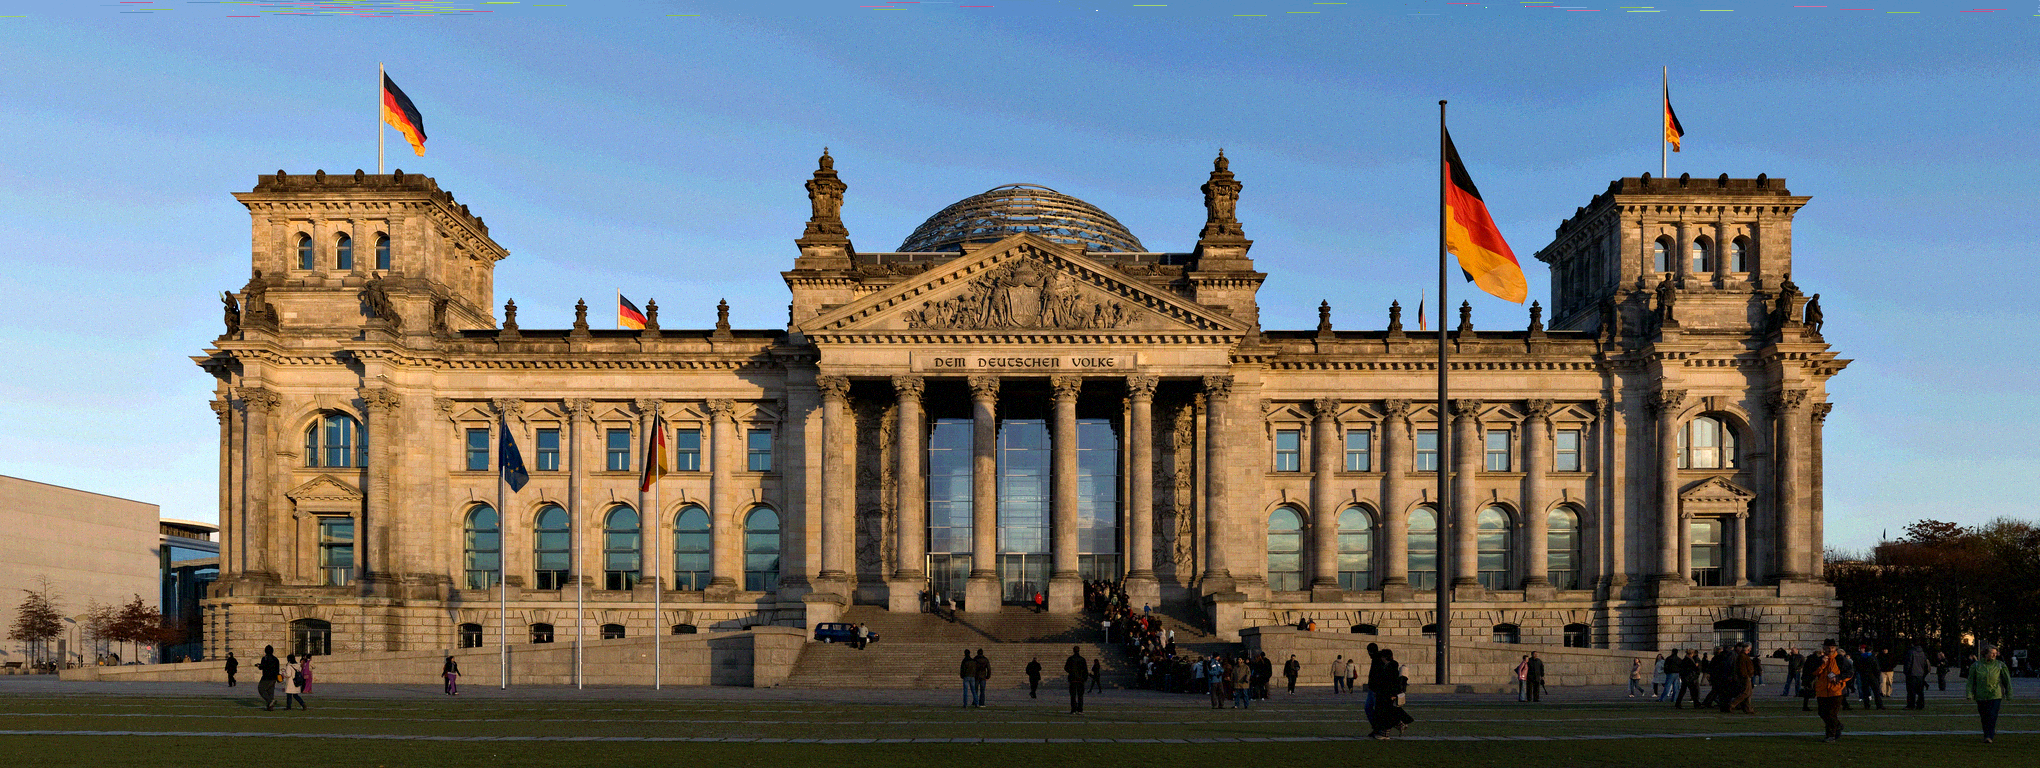

In [ ]:
# size and enc_str from previous step
dimension = (2040, 768)
img_rec = char_string_to_image_rgb(dimension, decrypted_msg, save_path="reconstructed_rgb.png")
img_rec.show()  # or open reconstructed_rgb.png manually


In [ ]:
def checkMatch(response, reference):
    wrong=0
    for i in range(len(reference)):
        if reference[i] != response[i]:
            wrong+=1
    return len(reference) - wrong

cur_length= len(decrypted_msg)
right = checkMatch(decrypted_msg, enc_str)

print("Extracted data acciracy ", right/cur_length*100)